In [17]:

import sys
import os
import gc

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# This adds the parent directory (..) to the Python path
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

import logging
from datasets import load_dataset
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW

from sklearn.linear_model import LinearRegression

from dataclasses import dataclass, field

from typing import List, Optional, Tuple, Any, Dict

from transformers import (
    PreTrainedModel,
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    TrainingArguments,
    TrainerCallback,
    Trainer,
    AutoModelForSequenceClassification,
    AutoConfig,
    get_linear_schedule_with_warmup
)

from transformers.activations import GELUActivation
from transformers.modeling_outputs import ModelOutput, SequenceClassifierOutput

DATA_DIR = Path("../data/")
MODELS_DIR = Path("../models/")
pos_list = ['noun',
            'adverb',
            'adjective',
            'verb',
            'preposition',
            'misc',
            'number',
            'not-no',
            'determiner']

/blue/jinnie.shin/zheli/.conda/envs/bea26/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
# utils.py
import random
import gc
import logging
import csv
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch

from torch.optim import AdamW
from sklearn.metrics import root_mean_squared_error, accuracy_score
from scipy.stats import pearsonr
from transformers import logging as hf_logging
from wordfreq import zipf_frequency

def configure_logging(verbose=False):
    """
    Configure logging for the pipeline.

    Args:
        verbose (bool): If True, set log level to DEBUG; else INFO.
    """
    # Determine log file path 
    logs_dir = Path("logs")
    logs_dir.mkdir(exist_ok=True)
    timestamp=datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    log_path = logs_dir / f"run_{timestamp}.log"

    # Root logger
    root = logging.getLogger()
    root.setLevel(logging.DEBUG if verbose else logging.INFO)
    root.handlers.clear()

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M"
    )

    # Console handler
    ch = logging.StreamHandler()
    ch.setFormatter(formatter)

    # File handler
    fh = logging.FileHandler(log_path)
    fh.setFormatter(formatter)

    # Add handlers
    for handler in (ch, fh):
        root.addHandler(handler)

    # Hugging Face logging
    if verbose:
        hf_logging.set_verbosity_debug()
    else:
        hf_logging.set_verbosity_warning()

    hf_logger = hf_logging.get_logger("transformers")
    hf_logger.propagate=False
    hf_logger.handlers.clear()
    for handler in (ch, fh):
        hf_logger.addHandler(handler)
        

def is_model_downloaded(model_folder):
    """
    Check if the Hugging Face model is downloaded.
    
    Args:
        model_folder (Path): Local path to model folder.
    
    Returns:
        bool: True if all required files exist, False otherwise.
    """

    REQUIRED_FILES = [
        "training_args.bin", 
        "tokenizer.json", 
        "special_tokens_map.json", 
        "tokenizer_config.json",
        "model.safetensors",
        "config.json",
    ]
    
    if not model_folder.exists():
        return False
    
    missing_files = [f for f in REQUIRED_FILES if not (model_folder / f).exists()]
    if missing_files:
        return False
    
    return True



def load_model_params(model_params_path, models_to_run):
    """
    Load the model parameters CSV and yield each row as a dict.

    Args:
        model_params_path (Path or str): Path to the CSV file containing model parameters.
        models_to_run (List[str]): List of model names to include.
    """
    with Path(model_params_path).open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            model_name = row.get("model_name")
            if model_name not in models_to_run:
                continue
            yield row


def load_data_paths(data_dir, l1, mode, dataset_split=None):
    """
    Loads CSV file paths for Hugging Face `load_dataset`.

    Returns a dictionary with keys 'train', 'validation', and 'test',
    mapping to lists of CSV paths. Keys with no files are omitted.

    Args:
        data_dir (Path): Base directory containing the data splits.
        l1 (str): Language code (e.g., 'es') or 'xx' to include all languages during finetune.
        mode (str): One of 'finetune', 'predict', or 'evaluate'.
        dataset_split (str or None): For predict/evaluate, which data splits to load:
            'dev', 'test', or 'both'. Ignored for finetune.

    Returns:
        dict: Mapping HF split names to lists of CSV paths, e.g.,
            {'train': ['train/es/file1.csv'], 'validation': ['dev/es/file1.csv']}
    """

    # for finetuning 'xx' means combine all L1s
    # L1s are separate for predict and evaluate
    l1_list = ["es", "de", "cn"] if mode == "finetune" and l1 == "xx" else [l1]

    data_files = {}

    # Mapping from KVL dataset split names to HF split names
    kvl_splits_to_hf = {
        "train": "train",
        "dev": "validation",
        "test": "test"
    }

    if mode == "finetune":
        train_files = []
        val_files = []

        for l1 in l1_list:
            train_folder=data_dir / "train" / l1
            val_folder=data_dir / "dev" / l1

            train_files.extend(str(f) for f in train_folder.glob("*.csv"))
            val_files.extend(str(f) for f in val_folder.glob("*.csv"))

        if train_files:
            data_files["train"] = train_files
        if val_files:
            data_files["validation"] = val_files

    elif mode in {"predict", "evaluate"}:
        
        splits_to_load = ["dev", "test"] if dataset_split == "both" else [dataset_split]

        for folder_name in splits_to_load:
            files = []
            for l1 in l1_list:
                folder = data_dir / folder_name / l1
                files.extend(str(f) for f in folder.glob("*.csv"))

            hf_key = kvl_splits_to_hf[folder_name]
            if files:
                data_files[hf_key] = files

    return data_files


def merge_cols(batch, cols_to_merge, sep_token):
    """
    Merge specified item text components into a single input string per example.

    Designed for use with Hugging Face `Dataset.map` in batched mode.

    Args:
        batch (dict): Batched dataset examples.
        cols_to_merge (list[str]): Ordered column names to concatenate.
        sep_token (str): Separator string between components.

    Returns:
        dict: Dictionary with key `"input_text"` containing merged text strings.
    """
    rows=zip(*(batch[col] for col in cols_to_merge))
    return {
        "input_text": [
            sep_token.join(str(x).strip() for x in row)
            for row in rows
        ]
    }


def preprocess_dataset(ds_dict, cols_to_merge, sep_token):
    """
    Preprocess a Hugging Face DatasetDict by:
        1. Merging specified text columns into a single 'input_text' column.
        2. Renaming the target column 'GLMM_score' to 'label'.
        3. Removing all other columns except 'input_text' and 'label'.

    Args:
        ds_dict (datasets.DatasetDict): Input DatasetDict with one or more splits.
        cols_to_merge (list[str]): List of text columns to concatenate into 'input_text'.
        sep_token (str): Separator string to insert between merged columns.

    Returns:
        datasets.DatasetDict: Preprocessed DatasetDict where each split contains only
            the columns 'input_text' and 'label', ready for tokenization.
    """
    
    # Compute columns to remove
    first_split = next(iter(ds_dict.values())) # get first key in ds_dict
    all_columns = first_split.column_names
    cols_to_keep = ["input_text", "labels", "en_target_pos"]
    cols_to_remove = [c for c in all_columns if c not in cols_to_keep and c != 'GLMM_score']
    
    # Format input text, rename target label and remove extra columns
    ds_dict = ds_dict.map(
        merge_cols,
        batched=True,
        fn_kwargs={"cols_to_merge": cols_to_merge, "sep_token": sep_token},
        desc="Formatting input text"
    ).rename_column("GLMM_score", "labels").remove_columns(cols_to_remove)
    
    return ds_dict

def compute_metrics(eval_pred):
    """
    Compute regression performance metrics for Hugging Face Trainer evaluation.

    Args:
        eval_pred (tuple): Tuple of (predictions, labels).

    Returns:
        dict: Dictionary containing RMSE and Pearson correlation.
    """  
    predictions, labels=eval_pred
    
    if isinstance(predictions, tuple):
        reg_preds = predictions[0]
        pos_logits = predictions[-1]
    else:
        # Fallback if only one task is returned
        reg_preds = predictions
        pos_logits = None
   
    if isinstance(labels, tuple) or (isinstance(labels, np.ndarray) and labels.ndim > 1 and labels.shape[1] > 1):
        # Depending on how the DataCollator/Trainer bundles labels:
        reg_labels = labels[0]
        pos_labels = labels[1]
    else:
        reg_labels = labels
        pos_labels = None

    results = {}
    
    reg_preds = reg_preds.flatten()
    reg_labels = reg_labels.flatten()
    
    results["rmse"] = root_mean_squared_error(reg_labels, reg_preds)
    results["pearson"], _ = pearsonr(reg_preds, reg_labels)

    # --- AUXILIARY TASK: POS Classification ---
    if pos_logits is not None and pos_labels is not None:
        # Get the predicted class index (Argmax)
        pos_preds = np.argmax(pos_logits, axis=-1).flatten()
        pos_labels = pos_labels.flatten()
        
        # Calculate Accuracy
        results["pos_accuracy"] = accuracy_score(pos_labels, pos_preds)
    
    return results


def print_evaluation_results(eval_results_df, decimals=3):
    """
    Print evaluation results for both tracks.

    Args:
        eval_results_df (pd.DataFrame): DataFrame with columns 'model', 'track', 'L1', and metric columns.
        decimals (int): Number of decimal places to round metrics.
    """

    # Ensure L1 is ordered as es, de, cn
    L1_order = ["es", "de", "cn"]
    eval_results_df["L1"] = pd.Categorical(eval_results_df["L1"], categories=L1_order, ordered=True)

    tables = [
        ("CLOSED TRACK", eval_results_df[eval_results_df["track"] == "closed"]),
        (
            "OPEN TRACK",
            eval_results_df[(eval_results_df["track"] == "open") & (eval_results_df["L1"] != "xx")],
        ),
    ]

    output_lines = []
    cols = ["model", "L1", "rmse", "pearson"]

    for title, df in tables:
        # Sort by L1 according to our categorical order
        df=df.sort_values("L1") 

        output_lines.extend([
            "",
            title,
            "-" * len(title),
        ])

        if df.empty:
            output_lines.append("<no results>")
        else:
            output_lines.append(df[cols].round(decimals).to_string(index=False))

    output_text = "\n".join(output_lines)

    logging.info(f"Evaluation summary:\n{output_text}")



def save_predictions(save_path, item_ids, predictions):
    """
    Save predictions to a CSV file, sorted by item_id.

    Args:
        save_path (Path): Path to save the CSV file.
        item_ids (list): List of item IDs corresponding to predictions.
        predictions (list or array): List of predicted values.
    """

    save_path.parent.mkdir(parents=True, exist_ok=True)

    # Create a DataFrame and sort by item_id
    df = pd.DataFrame({"item_id": item_ids, "prediction": predictions})
    df = df.sort_values("item_id")

    # Save to CSV
    df.to_csv(save_path, index=False)


def cleanup_trainer_memory(*objects):
    """
    Free up memory used by PyTorch and delete given objects.

    Args:
        *objects: Any Python objects (e.g., Trainer, datasets) to delete.
    """
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    for obj in objects:
        del obj



In [35]:
l1 = 'es'
backbone = 'jhu-clsp/mmBERT-base' # ['jhu-clsp/mmBERT-base', 'FacebookAI/xlm-roberta-base']
component_order = "L1_source_word; L1_context; en_target_clue; en_target_word"
dataset_split = 'both'
data_files = load_data_paths(DATA_DIR, l1, "predict", dataset_split=dataset_split)

In [36]:
data_files

{'validation': ['../data/dev/es/kvl_shared_task_es_dev.csv'],
 'test': ['../data/test/es/kvl_shared_task_es_test.csv']}

In [41]:
l1 = 'es'
backbone = 'jhu-clsp/mmBERT-base' # ['jhu-clsp/mmBERT-base', 'FacebookAI/xlm-roberta-base']
component_order = "L1_source_word; L1_context; en_target_clue; en_target_word"
dataset_split = 'both'
data_files = load_data_paths(DATA_DIR, l1, "predict", dataset_split=dataset_split)

hf_dataset = load_dataset("csv", data_files=data_files)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(backbone, use_fast=True)
cols_to_merge = component_order.split("; ")
sep_token = f" {tokenizer.sep_token} " if tokenizer.sep_token else " "

# Preprocess dataset: format input text, rename target label and remove extra columns
preprocessed_ds = preprocess_dataset(hf_dataset, cols_to_merge, sep_token)

In [43]:
tokenized_ds = preprocessed_ds.map(
    lambda x: tokenizer(x["input_text"], truncation=True),
    batched=True,
    desc="Tokenizing input text",
)

# Itemize POS
pos_to_idx = {pos:i for i, pos in enumerate(pos_list)}
tokenized_ds = tokenized_ds.map(
    lambda x: {"pos_labels": [pos_to_idx[val] for val in x['en_target_pos']]},
    batched=True,
    remove_columns=['en_target_pos'],
    desc="Itemizing POS tagging"
)

Itemizing POS tagging: 100%|██████████| 748/748 [00:00<00:00, 65308.17 examples/s]


In [48]:
tokenized_ds['validation'][0]

{'labels': -0.900103864,
 'input_text': 'extraña <eos> Esta situación es muy extraña y no entiendo nada. <eos> b______ <eos> bizarre',
 'input_ids': [2,
  179027,
  235248,
  1,
  22974,
  31422,
  875,
  7495,
  179027,
  597,
  793,
  147144,
  15297,
  235265,
  235248,
  1,
  518,
  28878,
  235248,
  1,
  55628,
  1],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'pos_labels': 2}

In [50]:
model = MultiTaskCascadeCustomModel.from_pretrained('../models/mbert-base_mtl_mlp_Max_cls_open_xx')

Loading weights: 100%|██████████| 143/143 [00:00<00:00, 3849.22it/s]


In [57]:
trainer = Trainer(
                    model=model,
                    data_collator=MultiTaskDataCollator(tokenizer),
                    
                )
trainer.predict(tokenized_ds['test'])

PredictionOutput(predictions=(array([[-8.18095624e-01],
       [ 3.02280247e-01],
       [-7.30422974e-01],
       [-1.18078065e+00],
       [-1.27206099e+00],
       [-8.11441183e-01],
       [-3.86406660e-01],
       [ 1.27316749e+00],
       [-1.13781750e+00],
       [ 1.97596657e+00],
       [ 2.02854443e+00],
       [-1.07301438e+00],
       [ 5.83346546e-01],
       [ 2.01142240e+00],
       [-8.33948016e-01],
       [ 1.05261052e+00],
       [ 7.66288996e-01],
       [ 1.51965380e-01],
       [-3.31424069e+00],
       [-1.17605793e+00],
       [ 1.26545584e+00],
       [ 2.20485258e+00],
       [ 1.89966595e+00],
       [ 1.22792840e+00],
       [ 5.83497584e-01],
       [ 3.06513858e+00],
       [-7.76542187e-01],
       [-1.75220096e+00],
       [ 6.67962611e-01],
       [ 4.85803448e-02],
       [-1.57034743e+00],
       [ 2.23842800e-01],
       [-2.03961909e-01],
       [-1.61642969e+00],
       [ 8.06132317e-01],
       [-1.39417243e+00],
       [ 1.49486446e+00],
       [

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import PreTrainedModel, AutoModel, AutoConfig, DataCollatorWithPadding
from transformers.modeling_outputs import ModelOutput

import copy
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Any, Dict


@dataclass
class CustomClassifierOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    hidden_states: Optional[Tuple[torch.FloatTensor]] = None
    attentions: Optional[Tuple[torch.FloatTensor]] = None
    token_attn_weights: Optional[torch.FloatTensor] = None
    
@dataclass
class MultiTaskClassifierOutput(CustomClassifierOutput):
    """Extends output to include auxiliary POS logits and loss."""
    pos_logits: torch.FloatTensor = None

@dataclass
class MultiTaskDataCollator(DataCollatorWithPadding):
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        # 1. Pop custom labels like you already are
        pos_labels = [f.pop("pos_labels") for f in features] if "pos_labels" in features[0] and features[0]["pos_labels"] is not None else None
        
        # 2. Safely remove standard 'labels' if they are None to prevent the base class crash
        for f in features:
            if "labels" in f and f["labels"] is None:
                del f["labels"]
            if "label" in f and f["label"] is None:
                del f["label"]

        # 3. Call the base class (which now only sees valid tensor-able data)
        batch = super().__call__(features)
        
        # 4. Add your custom labels back if they existed
        if pos_labels is not None:
            batch["pos_labels"] = torch.tensor(pos_labels, dtype=torch.long)
            
        return batch

class VIBHead(nn.Module):
    def __init__(self, config, latent_dim=64):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.activation = nn.Tanh()
        
        # 1. Encoder: Maps to Mean (mu) and Log-Variance (logvar)
        self.mu = nn.Linear(config.hidden_size, latent_dim)
        self.logvar = nn.Linear(config.hidden_size, latent_dim)
        
        # 2. Classifier: Maps latent Z -> Labels
        self.decoder = nn.Linear(latent_dim, config.num_labels)

    def reparameterize(self, mu, logvar):
        """
        The "Reparameterization Trick":
        z = mu + sigma * epsilon
        """
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            # During inference, we just use the mean (deterministic)
            return mu

    def forward(self, features):
        x = self.activation(self.dense(features))
        
        mu = self.mu(x)
        logvar = self.logvar(x)
        
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z)
        
        return logits, mu, logvar

class MaxPooling(nn.Module):
    def __init__(
        self,
        dim:int=0,
        cls_only:bool=True,
        **kwargs
    ) -> None:
        super().__init__()
        self.dim = dim
        self.cls_only = cls_only
    
    def forward(self, x, **kwargs):
        if self.cls_only:
            x = [layer[:, 0, :] for layer in x]
            x = torch.stack(x, self.dim).unsqueeze(-2)
        else:
            x = torch.stack(x, self.dim)
        return torch.max(x, self.dim).values

class MeanPooling(nn.Module):
    def __init__(
        self,
        dim:int=0,
        cls_only:bool=True
    ) -> None:
        super().__init__()
        self.dim = dim
        self.cls_only = cls_only
        
    def forward(self, x, **kwargs):
        if self.cls_only:
            x = [layer[:, 0, :] for layer in x]
            x = torch.stack(x, self.dim).unsqueeze(-2)
        else:
            x = torch.stack(x, self.dim)
        return torch.mean(x, self.dim)

class ScalarMix(nn.Module):
    def __init__(
        self, 
        mixture_size: int=13, 
        do_layer_norm: bool = True,
        initial_scalar_parameters: List[float] = None,
        trainable: bool = True
        ) -> None:
        """
        Layer mixing through global scalar weights. Adapted from [https://github.com/allenai/allennlp/blob/main/allennlp/modules/scalar_mix.py].
        Important implemenation strategy:
            - do_layer_norm: perform layer normalization for numerical stability.
            - trainable: whether the gamma parameter is trainable.
        """
        
        super().__init__()

        self.mixture_size = mixture_size
        self.do_layer_norm = do_layer_norm

        if initial_scalar_parameters is None:
            initial_scalar_parameters = torch.zeros((mixture_size,)) # zero initialization
        
        self.softmax = nn.Softmax(0)

        if not trainable:
            self.register_buffer('gamma', torch.tensor([1.0])) # If not trainable, Gamma is fixed
        else:
            self.gamma = nn.Parameter(torch.tensor([1.0]))

        self.scalar_weights = nn.Parameter(
            initial_scalar_parameters
            )
    
    def forward(
        self, 
        tensors: List[torch.Tensor],
        mask: torch.bool=None,
        **kwargs
        ) -> torch.Tensor:
        """
        Values:
            tensors = [layer_1, layer_2, ..., layer_n]
            weights = [w_1, ..., w_n]
        Formula:
            normed_weights = layer_norm(weights)
            output = gamma * sum(softmax(normed_weights) * tensors)
        Return:
            a batched tensor of the shape (batch_size, seq_len, hidden_size)
        """

        normed_weights = self.softmax(self.scalar_weights) # (mixture_size)
        
        mixed_tensor = None
        if self.do_layer_norm:
            assert mask is not None
            broadcast_mask = mask[None, :, :, None] # (1, batch_size, seq_len, 1)
            
            # Token-wise layer norm
            tensors = torch.stack(tensors, 0) # (n_layer, batch_size, seq_len, hidden_size)
            
            # PyTorch's provides off-the-shelf layer_norm function that is readily vectorized.  
            normed_tensors = F.layer_norm(tensors, normalized_shape=(tensors.size(-1), )) # tokenwise normalization: normalize across the last dimension only.
            # seq_len = tensors.size(-2) 
            # normed_tensors = F.layer_norm(tensors, normalized_shape=(tensors.size(-2), tensors.size(-1))) # sequencewise normalization: normalize across the last two dimensions
            normed_tensors = normed_tensors * broadcast_mask # masking normed tensors
            
            weights_shape = (-1,) + (1,) * (tensors.dim() - 1) # (-1, 1, 1, 1)
            normed_weights = normed_weights.view(weights_shape) # broadcastable to tensors
            mixed_tensor = torch.sum(normed_weights * normed_tensors, dim=0) # (1, batch_size, seq_len, hidden_size)

        else:
            # if no layer norm, by default we extract only the first token
            tensors = [layer[:, 0, :] for layer in tensors] # extract the first token (batch_size, seq_len, hidden_size) -> (batch_size, hidden_dim)
            tensors = torch.stack(tensors, 0) # (layer, batch_size, hidden_dim)
            tensors = F.layer_norm(tensors, normalized_shape=(tensors.size(-1),)) # normalize within token to prevent gradient explode.
            weights_shape = (-1,) + (1,) * (tensors.dim() - 1) # (-1, 1, 1)
            normed_weights = normed_weights.view(weights_shape) # broadcastable to tensors
            mixed_tensor = torch.sum(normed_weights * tensors, dim=0).unsqueeze(1) # (batch_size, 1, hidden_size)
        
        return self.gamma * mixed_tensor

class CustomModel(PreTrainedModel):
    # 1. Tell Hugging Face which configuration class to use
    config_class = AutoConfig
    
    @property
    def all_tied_weights_keys(self):
        """
        Overrides the internal HF tied weights tracker.
        This model is a regression/classification architecture, 
        so it does not use tied weights (unlike language models).
        """
        return {}
    
    @property
    def backbone(self):
        if hasattr(self, 'roberta'):
            return self.roberta
        elif hasattr(self, 'model'):
            return self.model
        raise AttributeError("Backbone not initialized properly.")
    
    def __init__(self, config, **kwargs):
        
        super().__init__(config)
        
        # --- CONFIGURATION BINDING ---
        # We save any custom arguments into the config. 
        # This guarantees they are permanently written to `config.json` when you save the model!
        for k, v in kwargs.items():
            setattr(config, k, v)
            
        self.pred_head = getattr(config, 'pred_head', 'mlp')
        self.token_pool = getattr(config, 'token_pool', 'cls')
        self.dropout = getattr(config, 'dropout', 0.1)
        
        model_type = config.model_type
        
        # --- BUILD THE SKELETON (NO WEIGHTS LOADED HERE) ---
        if model_type in ['xlm-roberta', 'roberta']:
            self.base_model_prefix = "roberta"
            self.roberta = AutoModel.from_config(config, add_pooling_layer=False)
        elif model_type in ['modernbert']:
            self.base_model_prefix = "model"
            self.model = AutoModel.from_config(config)
        else:
            raise NotImplementedError(f"Backbone '{model_type}' is not supported by this predictor.")

        # --- BUILD THE REGRESSION HEAD ---
        hidden_size = config.hidden_size
        
        if self.pred_head == 'mlp':
            if model_type in ['xlm-roberta', 'roberta']:
                self.regressor = nn.Sequential(
                    nn.Dropout(self.dropout),
                    nn.Linear(hidden_size, hidden_size),
                    nn.Tanh(),
                    nn.Dropout(self.dropout),
                    nn.Linear(hidden_size, 1)
                )
            elif model_type in ['modernbert']:
                self.regressor = nn.Sequential(
                    nn.Linear(hidden_size, hidden_size, bias=config.classifier_bias),
                    nn.GELU(),
                    nn.LayerNorm(hidden_size, eps=config.norm_eps, bias=config.norm_bias),
                    nn.Dropout(self.dropout),
                    nn.Linear(hidden_size, 1)
                    )
                
        elif self.pred_head == 'vib':
            self.beta = getattr(config, 'annealing_factor', 0.1)
            self.regressor = VIBHead(config, getattr(config, "latent_dim", 64))
        else:
            self.regressor = nn.Sequential(
                nn.Dropout(self.dropout),
                nn.Linear(hidden_size, 1)
            )
            
        self.layer_pool = getattr(config, 'layer_pool', None)
        self.last_k_layer = getattr(config, 'last_k_layer', None)
        if self.layer_pool:
            if self.layer_pool == 'scalarmix':
                self.layer_pooler = ScalarMix(
                    self.last_k_layer if self.last_k_layer is not None else config.num_hidden_layers + 1,
                    do_layer_norm= self.layer_pool != 'cls',
                    trainable=True
                )
            elif self.layer_pool == 'max':
                self.layer_pooler = MaxPooling(
                    dim = 0,
                    cls_only = self.layer_pool == 'cls'
                )
            elif self.layer_pool == 'mean':
                self.layer_pooler = MeanPooling(
                    dim = 0,
                    cls_only = self.layer_pool == 'cls'
                )

        # initiate token fusion strategy
        self.token_pool = getattr(config, 'token_pool', 'cls')
        if self.token_pool == 'mha':
            if getattr(config, 'num_heads', None) is None:
                raise ValueError(f'The number of multiple heads is not defined!')
            if config.hidden_size % config.num_heads != 0:
                raise ValueError(f"The hidden size ({config.hidden_size}) must be a multiple of num_heads ({config.num_heads}).")
            self.token_pooler = nn.MultiheadAttention(
                embed_dim=hidden_size,
                num_heads=config.num_heads,
                dropout=self.dropout,
                batch_first=True
            )
        else:
            self.token_pooler = None
            
    def forward(
        self,
        input_ids,
        attention_mask,
        labels=None,
        **kwargs
    ) -> CustomClassifierOutput:
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )

        if self.layer_pool:
            hiddens = list(outputs.hidden_states)[-self.last_k_layer:] if self.last_k_layer is not None else list(outputs.hidden_states)
            output_hiddens = self.layer_pooler(hiddens, mask=attention_mask)
        else:
            output_hiddens = outputs.last_hidden_state

        pooled_output, attn_weights = self._perform_token_pooling(output_hiddens, 
                                                                  attention_mask, 
                                                                  self.token_pool, 
                                                                  self.token_pooler
                                                                  )
        
        loss = None
        if self.pred_head == 'vib':        
            logits, mu, logvar = self.regressor(pooled_output)
            
            if labels is not None:
                loss_fct = nn.MSELoss(reduction='sum')
                pred_loss = loss_fct(logits.view(-1), labels.view(-1)) / pooled_output.size(0)

                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                kl_loss = kl_loss / pooled_output.size(0)

                loss = pred_loss + (self.beta * kl_loss)
                
        else:
            logits = self.regressor(pooled_output)
            
            if labels is not None:
                loss_fct = nn.MSELoss()
                loss = loss_fct(logits.view(-1), labels.view(-1))      
                
        return CustomClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
            token_attn_weights=attn_weights
        )
    
    @staticmethod
    def _perform_token_pooling(hiddens, mask, pool_type, pooler_module):
        """Helper to ensure logic parity between paths."""
        # Default CLS
        hiddens_out = hiddens[:, 0, :]
        attn_weights = None
        if pool_type == 'mean':
            m_float = mask.to(hiddens.dtype)
            hiddens_out = (hiddens * m_float.unsqueeze(-1)).sum(dim=1) / torch.clamp(m_float.sum(dim=1, keepdim=True), min=1e-4)

        elif pool_type == 'mha' and pooler_module:
            cls_h = hiddens[:, 0, :].unsqueeze(1)
            p_mask = ~mask.to(torch.bool)
            attn_out, ave_attn_weights = pooler_module(
                query=cls_h, 
                key=hiddens, 
                value=hiddens, 
                key_padding_mask=p_mask, 
                need_weights=True,
                average_attn_weights=True
                )
            hiddens_out = attn_out[:, 0, :]
            attn_weights = ave_attn_weights[:,0,:]
            
        return hiddens_out, attn_weights
        
        
class MultiTaskCustomModel(CustomModel):
    def __init__(self, config, **kwargs):
        super().__init__(config, **kwargs)
        
        # --- AUXILIARY POS HEAD ---
        self.num_pos_labels = getattr(config, 'num_pos_labels', 7) 
        
        # Classification head for the single POS label
        self.pos_classifier = copy.deepcopy(self.regressor)
        
        # same but separate layer_pooler and token_pooler:
        if hasattr(self, 'token_pooler') and self.token_pooler is not None:
            self.pos_token_pooler = copy.deepcopy(self.token_pooler)
        else:
            self.pos_token_pooler = None
            
        if hasattr(self, 'layer_pooler') and self.layer_pooler is not None:
            self.pos_layer_pooler = copy.deepcopy(self.layer_pooler)
        else:
            self.pos_layer_pooler = None
        
        if isinstance(self.pos_classifier, nn.Sequential):
            last_layer_idx = len(self.pos_classifier) - 1
            in_features = self.pos_classifier[last_layer_idx].in_features
            self.pos_classifier[last_layer_idx] = nn.Linear(in_features, self.num_pos_labels)
        else:
            # Fallback if regressor is a single Linear layer
            in_features = self.pos_classifier.in_features
            self.pos_classifier = nn.Linear(in_features, self.num_pos_labels)
            
        self.log_vars = nn.Parameter(torch.zeros(2))

    def forward(
        self,
        input_ids,
        attention_mask,
        labels=None,      # Primary Task (Difficulty - Float)
        pos_labels=None,  # Auxiliary Task (POS - Long/Int)
        **kwargs
    ) -> MultiTaskClassifierOutput:
        
        # Use your established backbone + pooling logic
        # This gives us the pooled_output used for regression
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # --- PATH A: PRIMARY REGRESSION (Difficulty) ---
        # 1. Layer Pooling
        if self.layer_pool:
            h_reg = list(outputs.hidden_states)[-self.last_k_layer:] if self.last_k_layer else list(outputs.hidden_states)
            out_h_reg = self.layer_pooler(h_reg, mask=attention_mask)
        else:
            out_h_reg = outputs.last_hidden_state

        # 2. Token Pooling
        p_out_reg, primary_token_attn_weights = self._perform_token_pooling(out_h_reg, attention_mask, self.token_pool, self.token_pooler)
        logits = self.regressor(p_out_reg)

        # --- PATH B: AUXILIARY CLASSIFICATION (POS) ---
        # 1. Layer Pooling (Independent Weights)
        if self.pos_layer_pooler:
            h_pos = list(outputs.hidden_states)[-self.last_k_layer:] if self.last_k_layer else list(outputs.hidden_states)
            out_h_pos = self.pos_layer_pooler(h_pos, mask=attention_mask)
        else:
            out_h_pos = outputs.last_hidden_state

        # 2. Token Pooling (Independent Weights)
        p_out_pos, _ = self._perform_token_pooling(out_h_pos, attention_mask, self.token_pool, self.pos_token_pooler)
        pos_logits = self.pos_classifier(p_out_pos)
            
        primary_loss = None
        pos_loss = None

        # 1. Primary Regression Loss
        if labels is not None:
            loss_fct_reg = nn.MSELoss(reduction='mean')
            primary_loss = loss_fct_reg(logits.view(-1), labels.view(-1))

        # 2. Auxiliary Classification Loss (Single Label per sequence)
        if pos_labels is not None:
            loss_fct_pos = nn.CrossEntropyLoss(reduction='mean')
            pos_loss = loss_fct_pos(pos_logits.view(-1, self.num_pos_labels), pos_labels.view(-1))
            
        total_loss = None
        if primary_loss is not None and pos_loss is not None:
            safe_log_var0 = torch.clamp(self.log_vars[0], min=-10.0, max=10.0)
            safe_log_var1 = torch.clamp(self.log_vars[1], min=-10.0, max=10.0)
            loss1 = torch.exp(-safe_log_var0) * primary_loss + safe_log_var0
            loss2 = torch.exp(-safe_log_var1) * pos_loss + safe_log_var1
            total_loss = loss1 + loss2
            
        return MultiTaskClassifierOutput(
            loss=total_loss,
            logits=logits,
            pos_logits=pos_logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
            token_attn_weights=primary_token_attn_weights
        )

class MultiTaskCascadeCustomModel(CustomModel):
    def __init__(self, config, **kwargs):
        # 1. Initialize the Base Model (Builds the backbone and standard regressor)
        super().__init__(config, **kwargs)
        
        self.num_pos_labels = getattr(config, 'num_pos_labels', 20) # Ensure this matches your dataset!
        hidden_size = config.hidden_size
        
        # ==========================================
        # 2. BUILD THE INDEPENDENT POS PATH
        # ==========================================
        self.pos_classifier = copy.deepcopy(self.regressor)
        
        # Deepcopy poolers so they have independent weights
        self.pos_token_pooler = copy.deepcopy(self.token_pooler) if hasattr(self, 'token_pooler') and self.token_pooler else None
        self.pos_layer_pooler = copy.deepcopy(self.layer_pooler) if hasattr(self, 'layer_pooler') and self.layer_pooler else None

        # Fix the POS classifier's output dimension (from 1 to num_pos_labels)
        if isinstance(self.pos_classifier, nn.Sequential):
            last_idx = len(self.pos_classifier) - 1
            in_features = self.pos_classifier[last_idx].in_features
            self.pos_classifier[last_idx] = nn.Linear(in_features, self.num_pos_labels)
        elif hasattr(self.pos_classifier, 'dense'): # Catch VIB Head
            in_features = self.pos_classifier.decoder.in_features
            self.pos_classifier.decoder = nn.Linear(in_features, self.num_pos_labels)
        else:
            in_features = self.pos_classifier.in_features
            self.pos_classifier = nn.Linear(in_features, self.num_pos_labels)

        # ==========================================
        # 3. WIDEN THE PRIMARY REGRESSOR (FEATURE INJECTION)
        # ==========================================
        combined_dim = hidden_size + self.num_pos_labels
        
        if isinstance(self.regressor, nn.Sequential):
            # Find the very first Linear layer and widen its input dimension
            for i, module in enumerate(self.regressor):
                if isinstance(module, nn.Linear):
                    out_features = module.out_features
                    self.regressor[i] = nn.Linear(combined_dim, out_features, bias=module.bias is not None)
                    break
        elif hasattr(self.regressor, 'dense'): # Catch VIB Head
            self.regressor.dense = nn.Linear(combined_dim, hidden_size)
        else:
            out_features = self.regressor.out_features
            self.regressor = nn.Linear(combined_dim, out_features)

        # 4. Learned Log-Variances for Dynamic Precision Weighting
        self.log_vars = nn.Parameter(torch.zeros(2))

    def forward(
        self,
        input_ids,
        attention_mask,
        labels=None,      # Primary Task (Difficulty)
        pos_labels=None,  # Auxiliary Task (POS)
        **kwargs
    ) -> MultiTaskClassifierOutput:
        
        # --- THE SHARED BACKBONE (Runs Only Once for Speed/Memory) ---
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )

        # --- PATH A: AUXILIARY CLASSIFICATION (Runs First) ---
        if self.pos_layer_pooler:
            h_pos = list(outputs.hidden_states)[-self.last_k_layer:] if self.last_k_layer else list(outputs.hidden_states)
            out_h_pos = self.pos_layer_pooler(h_pos, mask=attention_mask)
        else:
            out_h_pos = outputs.last_hidden_state

        p_out_pos, _ = self._perform_token_pooling(out_h_pos, attention_mask, self.token_pool, self.pos_token_pooler)
        
        # Handle VIB vs Standard
        if self.pred_head == 'vib':
            pos_logits, _, _ = self.pos_classifier(p_out_pos)
        else:
            pos_logits = self.pos_classifier(p_out_pos)


        # --- PATH B: PRIMARY REGRESSION (The Cascade) ---
        if self.layer_pool:
            h_reg = list(outputs.hidden_states)[-self.last_k_layer:] if self.last_k_layer else list(outputs.hidden_states)
            out_h_reg = self.layer_pooler(h_reg, mask=attention_mask)
        else:
            out_h_reg = outputs.last_hidden_state

        p_out_reg, primary_token_attn_weights = self._perform_token_pooling(out_h_reg, attention_mask, self.token_pool, self.token_pooler)
        
        # 🟢 FEATURE INJECTION MAGIC 
        # Combine the semantic backbone features with the explicit POS knowledge.
        # .detach() ensures the primary loss doesn't ruin the POS classifier's weights.
        combined_features = torch.cat([p_out_reg, pos_logits.detach()], dim=-1)

        if self.pred_head == 'vib':
            logits, mu, logvar = self.regressor(combined_features)
        else:
            logits = self.regressor(combined_features)
            
        # --- LOSS CALCULATION ---
        primary_loss = None
        if labels is not None:
            if self.pred_head == 'vib':
                pred_loss = nn.MSELoss(reduction='sum')(logits.view(-1), labels.view(-1)) / p_out_reg.size(0)
                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / p_out_reg.size(0)
                primary_loss = pred_loss + (self.beta * kl_loss)
            else:
                primary_loss = nn.MSELoss(reduction='mean')(logits.view(-1), labels.view(-1))

        pos_loss = None
        if pos_labels is not None:
            # ignore_index=-1 safely handles null POS tags without crashing CUDA
            pos_loss = nn.CrossEntropyLoss(reduction='mean', ignore_index=-1)(
                pos_logits.view(-1, self.num_pos_labels), pos_labels.view(-1)
            )

        # --- DYNAMIC PRECISION WEIGHTING ---
        total_loss = None
        if primary_loss is not None and pos_loss is not None:
            # 🟢 NaN PROTECTION: Clamp exponents to safe FP16 boundaries
            safe_log_var0 = torch.clamp(self.log_vars[0], min=-10.0, max=10.0)
            safe_log_var1 = torch.clamp(self.log_vars[1], min=-10.0, max=10.0)

            loss1 = torch.exp(-safe_log_var0) * primary_loss + safe_log_var0
            loss2 = torch.exp(-safe_log_var1) * pos_loss + safe_log_var1
            total_loss = loss1 + loss2
            
        return MultiTaskClassifierOutput(
            loss=total_loss,
            logits=logits,
            pos_logits=pos_logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
            token_attn_weights=primary_token_attn_weights
        )

In [26]:
import random
import pandas as pd

# Ensure deterministic behavior for reproducibility
random.seed(1234)
np.random.seed(1234)

pos_list = ['noun',
 'adverb',
 'adjective',
 'verb',
 'preposition',
 'misc',
 'number',
 'not-no',
 'determiner'
 ]

# 1) Dataset prep helper

def prepare_datasets_backbone(backbone, component_order, l1, batch_size):
    data_files = load_data_paths(DATA_DIR, l1, "finetune")
    hf_dataset = load_dataset("csv", data_files=data_files)

    tokenizer = AutoTokenizer.from_pretrained(backbone, use_fast=True)
    cols_to_merge = component_order.split("; ")
    sep_token = f" {tokenizer.sep_token} " if tokenizer.sep_token else " "

    preprocessed_ds = preprocess_dataset(hf_dataset, cols_to_merge, sep_token)

    tokenized_ds = preprocessed_ds.map(
        lambda x: tokenizer(x["input_text"], truncation=True),
        batched=True,
        desc="Tokenizing input text"
    ).remove_columns('input_text')
    
    # itemize_pos
    pos_to_idx = {pos:i for i, pos in enumerate(pos_list)}
    tokenized_ds = tokenized_ds.map(
        lambda x: {"pos_labels": [pos_to_idx[val] for val in x['en_target_pos']]},
        batched=True,
        remove_columns=['en_target_pos'],
        desc="Itemizing POS tagging"
    )

    return tokenized_ds, pos_to_idx

In [28]:
# model_name = "mbert-base_mlp_Max_mean_last4_4_ft_xx"
backbone = 'jhu-clsp/mmBERT-base' # ['jhu-clsp/mmBERT-base', 'FacebookAI/xlm-roberta-base']
component_order = "L1_source_word; L1_context; en_target_clue; en_target_word"
batch_size = 64
l1 = 'xx'
lr = 5e-5
wd = 0.1
warmup_steps=200
epoch = 5

tokenized_ds, pos_to_idx = prepare_datasets_backbone(backbone, component_order, l1, batch_size)
tokenizer = AutoTokenizer.from_pretrained(backbone, use_fast=True)

training_args = TrainingArguments(
    # output_dir=str(MODELS_DIR / model_name),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    label_names=["labels", "pos_labels"],
    save_total_limit=1,
    num_train_epochs=int(epoch),
    per_device_train_batch_size=int(batch_size),
    per_device_eval_batch_size=int(batch_size),
    learning_rate=float(lr),
    bf16=True,
    weight_decay=float(wd),
    warmup_steps=int(warmup_steps),
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    report_to="none",
    seed=1234,
)

config = AutoConfig.from_pretrained(
    backbone,
    num_labels=1
)

config.update({
    'pred_head':"mlp", 
    'token_pool':"mha".lower(),
    'layer_pool':'Max'.lower(),
    'dropout':0.1,
    'last_k_layer':int("last4"[-1]),
    'num_heads':4,
    'num_pos_labels': len(pos_list)
})

final_model = MultiTaskCascadeCustomModel.from_pretrained(
    backbone, 
    config=config  
)

data_collator = MultiTaskDataCollator(tokenizer)

trainer = Trainer(
    model=final_model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

train_state = trainer.train()

Loading weights: 100%|██████████| 134/134 [00:00<00:00, 64780.63it/s]
MultiTaskCascadeCustomModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key                              | Status     | 
---------------------------------+------------+-
head.norm.weight                 | UNEXPECTED | 
decoder.weight                   | UNEXPECTED | 
head.dense.weight                | UNEXPECTED | 
decoder.bias                     | UNEXPECTED | 
regressor.{0, 2, 4}.weight       | MISSING    | 
pos_token_pooler.in_proj_bias    | MISSING    | 
pos_classifier.4.bias            | MISSING    | 
token_pooler.in_proj_weight      | MISSING    | 
pos_classifier.{0, 2, 4}.weight  | MISSING    | 
token_pooler.out_proj.bias       | MISSING    | 
regressor.4.bias                 | MISSING    | 
token_pooler.out_proj.weight     | MISSING    | 
pos_token_pooler.in_proj_weight  | MISSING    | 
log_vars                         | MISSING    | 
pos_token_pooler.out_proj.bias   | MISSING    | 
token_pooler.in_proj_bias     

Epoch,Training Loss,Validation Loss,Rmse,Pearson,Pos Accuracy
1,2.879467,1.644825,1.204643,0.768821,0.940423
2,1.017516,1.380861,1.131146,0.815889,0.961595
3,0.438173,1.139686,1.030079,0.823520,0.972427
4,0.146340,1.113476,1.021757,0.827404,0.973412
5,0.015810,1.108046,1.016340,0.828357,0.974397


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.76s/it]


In [196]:
trainer.save_model(MODELS_DIR / model_name)
tokenizer.save_pretrained(MODELS_DIR / model_name)

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.93s/it]


('../models/mbert-base_mlp_Max_mean_last4_4_ft_xx/tokenizer_config.json',
 '../models/mbert-base_mlp_Max_mean_last4_4_ft_xx/tokenizer.json')

In [225]:
sample_batch = next(iter(DataLoader(
    tokenized_ds['train'],
    batch_size=32,
    collate_fn=DataCollatorWithPadding(tokenizer)
)))

In [ ]:
hf_default_dropout = config.classifier_dropout if config.classifier_dropout is not None else 0.2
final_model = AdvancedAggregatorModel(
                        config=config, 
                        dropout=hf_default_dropout,
                        tok_dropout=hf_default_dropout,
                        layer_pool='psum',
                        token_pool='cls',
                        pred_head='mlp',
                        last_k_layer=4,
                        num_heads=4,
                        freeze_backbone=True
                    )

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 28678.26it/s]
XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [230]:
input_ids = sample_batch['input_ids']
attention_mask = sample_batch['attention_mask']

final_model.to('cpu')

outputs = final_model.backbone(input_ids, 
      attention_mask,
      output_hidden_states=True)
# hiddens = list(outputs.hidden_states)[-4:][::-1]

In [234]:
vib = VIBHead(config, 64)
vib(outputs.last_hidden_state[:,0,:])[0].shape

torch.Size([32, 2])

In [68]:
extended_attention_mask = final_model.backbone.get_extended_attention_mask(
            attention_mask, input_ids.size()
        )

In [ ]:
input_ids = sample_batch['input_ids']
attention_mask = sample_batch['attention_mask']

outputs = final_model.backbone(input_ids, 
      attention_mask,
      output_hidden_states=True)
hiddens = list(outputs.hidden_states)[-4:][::-1]

extended_attention_mask = final_model.backbone.get_extended_attention_mask(
            attention_mask, input_ids.size()
        )


In [74]:
mha_module = nn.MultiheadAttention(
    embed_dim = config.hidden_size,
    num_heads = 4,
    dropout=hf_default_dropout,
    batch_first=True
    )

attention_mask = sample_batch['attention_mask']
last_hidden_state = outputs.last_hidden_state
last_cls_hidden = outputs.last_hidden_state[:, 0, :].unsqueeze(1)
padding_masks = ~attention_mask.to(torch.bool)
output_hiddens, attn_weights = mha_module(
    query=last_cls_hidden,
    key=last_hidden_state,
    value=last_hidden_state,
    key_padding_mask=padding_masks,
    need_weights=True,
    average_attn_weights=True
)
output_hiddens = output_hiddens[:, 0, :]

In [ ]:
from argparse import Namespace
import numpy as np
import pandas as pd
import os
from pathlib import Path

DATA_DIR = Path('../data')

def load_file_path(mode, DATA_DIR=DATA_DIR):

    kv1_file_path = {
        'train': [],
        'dev': [],
        'test': []
    }

    if mode == 'explore':   
        for l1 in ['cn', 'es', 'de']:
            train_folder = DATA_DIR / 'train' / l1
            dev_folder = DATA_DIR / 'dev' / l1
            kv1_file_path['train'].append(
                next(iter(train_folder.glob("*.csv")))
                )
            kv1_file_path['dev'].append(
                next(iter(dev_folder.glob("*.csv")))
                )
    
    return kv1_file_path

def load_data_from_path(mode, kv1_file_path):
    if mode == 'explore':
        train_df = pd.concat([pd.read_csv(f) for f in kv1_file_path['train']], axis=0, ignore_index=True)
        dev_df = pd.concat([pd.read_csv(f) for f in kv1_file_path['dev']], axis=0, ignore_index=True)
        df = pd.concat([train_df, dev_df],
        axis = 0,
        keys = ['train', 'dev'],
        names = ['split']
        ).reset_index(level = ['split']).reset_index(drop=True)
    
    return df

from wordfreq import zipf_frequency
def compute_frequency(w):
    """
    zipf_freq: Zipf frequency of a given word based on corpus used by wordfreq
    rare_ind: whether the given word has a zipf frequency lower than 3.
    is_common: whether the given word appears in the top 10 bucket on BNC frequency list, which is considered very common word. Words not on the list are automatically assigned zero. 
    """
    w = w.lower()
    zipf_freq = zipf_frequency(w, lang='en')
    return zipf_freq

In [26]:
kv1_file_path = load_file_path('explore', DATA_DIR)
df = load_data_from_path('explore', kv1_file_path)
df['zipf_freq'] = df['en_target_word'].map(compute_frequency)

--- CROSS-LINGUAL EVALUATION (RMSE) ---
            Test_de  Test_es  Test_cn  Test_all
Train_Data                                     
de            1.697    1.753    1.440     1.636
es            1.698    1.751    1.434     1.634
cn            1.721    1.756    1.413     1.637
all           1.701    1.748    1.423     1.630


Saved residual analysis plots to 'zipf_residual_analysis.png'
--- UNIVERSAL PRIOR SIGNIFICANCE ---
Global Pearson Correlation (r): 0.434 (p-value: 0.00e+00)
Global Explained Variance (R^2): 0.189

--- RESIDUAL BIAS BY LANGUAGE ---
   L1  Mean Bias (Error)  Residual StdDev
0  cn              0.011            1.385
1  de             -0.021            1.652
2  es              0.009            1.733


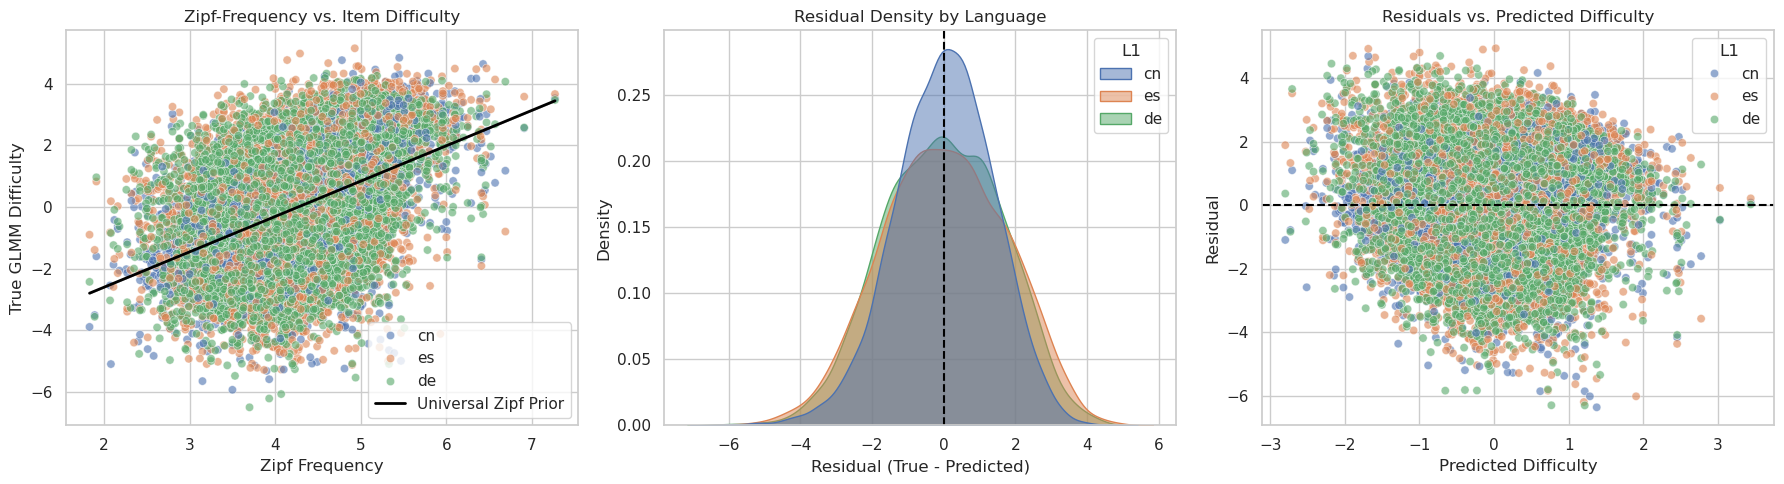

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import pearsonr

kv1_file_path = load_file_path('explore', DATA_DIR)
df = load_data_from_path('explore', kv1_file_path)
df['zipf_freq'] = df['en_target_word'].map(compute_frequency)
languages = ['de', 'es', 'cn', 'all']

# ==========================================
# 2. CROSS-LINGUAL EVALUATION MATRIX
# ==========================================
print("--- CROSS-LINGUAL EVALUATION (RMSE) ---")
results = []

for train_lang in languages:
    # Prepare Training Data
    if train_lang == 'all':
        train_df = df[df['split'] == 'train']
    else:
        train_df = df[(df['L1'] == train_lang) & (df['split'] == 'train')]
        
    X_train = train_df[['zipf_freq']]
    y_train = train_df['GLMM_score']
    
    # Fit the Zipf Prior Baseline
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    row = {'Train_Data': train_lang}
    
    for test_lang in languages:
        # Prepare Testing Data
        if test_lang == 'all':
            test_df = df[df['split'] == 'dev']
        else:
            test_df = df[(df['L1'] == test_lang) & (df['split'] == 'dev')]
            
        X_test = test_df[['zipf_freq']]
        y_test = test_df['GLMM_score']
        
        # Predict & Evaluate
        y_pred = model.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        row[f'Test_{test_lang}'] = rmse
        
    results.append(row)

results_df = pd.DataFrame(results).set_index('Train_Data')
print(results_df.round(3))
print("\n")

# ==========================================
# 3. RESIDUAL ANALYSIS (Using the 'ALL' Model)
# ==========================================
# We train a universal model on all data to analyze the residuals globally
universal_model = LinearRegression()
universal_model.fit(df[['zipf_freq']], df['GLMM_score'])

df['predicted_GLMM_score'] = universal_model.predict(df[['zipf_freq']])
# Residual formula: r = True - Predicted
df['residual'] = df['GLMM_score'] - df['predicted_GLMM_score'] 

# Set up the visualization grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# --- Plot 1: The Predictive Fit ---
sns.scatterplot(data=df, x='zipf_freq', y='GLMM_score', hue='L1', alpha=0.6, ax=axes[0])
sns.lineplot(data=df, x='zipf_freq', y='predicted_GLMM_score', color='black', linewidth=2, label='Universal Zipf Prior', ax=axes[0])
axes[0].set_title('Zipf-Frequency vs. Item Difficulty')
axes[0].set_xlabel('Zipf Frequency')
axes[0].set_ylabel('True GLMM Difficulty')

# --- Plot 2: Residual Distribution by Language ---
sns.kdeplot(data=df, x='residual', hue='L1', fill=True, common_norm=False, alpha=0.5, ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Density by Language')
axes[1].set_xlabel('Residual (True - Predicted)')

# --- Plot 3: Homoscedasticity (Residuals vs Predicted) ---
sns.scatterplot(data=df, x='predicted_GLMM_score', y='residual', hue='L1', alpha=0.6, ax=axes[2])
axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_title('Residuals vs. Predicted Difficulty')
axes[2].set_xlabel('Predicted Difficulty')
axes[2].set_ylabel('Residual')

plt.tight_layout()
# plt.savefig("zipf_residual_analysis.png", dpi=300)
# print("Saved residual analysis plots to 'zipf_residual_analysis.png'")

# ==========================================
# 4. STATISTICAL SIGNIFICANCE & BIAS REPORT
# ==========================================
print("--- UNIVERSAL PRIOR SIGNIFICANCE ---")
r, p_val = pearsonr(df['zipf_freq'], df['GLMM_score'])
r2 = r2_score(df['GLMM_score'], df['predicted_GLMM_score'])
print(f"Global Pearson Correlation (r): {r:.3f} (p-value: {p_val:.2e})")
print(f"Global Explained Variance (R^2): {r2:.3f}")

print("\n--- RESIDUAL BIAS BY LANGUAGE ---")
# If the mean residual is significantly non-zero, the Zipf prior is systematically 
# under-predicting or over-predicting for that specific language.
bias_report = df.groupby('L1')['residual'].agg(['mean', 'std']).reset_index()
bias_report.rename(columns={'mean': 'Mean Bias (Error)', 'std': 'Residual StdDev'}, inplace=True)
print(bias_report.round(3))

In [93]:
for row in load_model_params(MODELS_DIR / "model_parameters_new.csv", 'xlm-base_mlp_psum_cls_last4_fr_xx'):
    freeze_backbone_raw = row.get('train').lower() if row.get('train') else None
    freeze_backbone = (freeze_backbone_raw == 'fr')

In [13]:
final_model = pd.read_csv('../models/model_parameters_final.csv')['model_name'].tolist()

In [23]:
import csv
import itertools

# --- 1. Define the Grid Parameters ---
model_name = [name[:-8] for name in final_model]
track = ['open', 'closed']
L1 = ['xx', 'cn', 'de', 'es']

# --- 2. Generate All Combinations ---
# itertools.product creates the Cartesian product (all possible combinations)
combinations = itertools.product(
    model_name, track, L1
)

rows = []
skipped_count = 0

for n, t, l in combinations:
    # Safely cast None to empty strings for the CSV
    t = t if t is not None else ""
    l_str = l if l is not None else ""
    
    skip_reason = None
    
    if t == 'open':
        if l_str in ['cn', 'de', 'es']:
            skip_reason = "Open tract evaluates on the entire data"
    else:
        if l_str == 'xx':
            skip_reason = 'Close tract evaluates only on separate L1 data'
    
    
    if skip_reason:
        skipped_count += 1
        continue
    
    name_parts = [n, t, l]

    model_name = "_".join([part for part in name_parts if part != ""])
    
    row = {
        "model_name": model_name.replace("/", "-"), # Replace '/' so it's a safe directory name
        "track": t,
        "pretrained_model": 'jhu-clsp/mmBERT-base',
        'mtl': 1,
        "L1": l_str
    }
    
    rows.append(row)
    
    

In [1]:
import csv
import itertools

# --- 1. Define the Grid Parameters ---
backbones = ['jhu-clsp/mmBERT-base']
track = ['open']
mtl = [None, 'mtl']
L1 = ['xx', 'cn', 'de', 'es']
component_order = 'L1_source_word; L1_context; en_target_clue; en_target_word'
batch_size = 64
epochs = 5  # Added to populate the requested 'epochs' column
pred_heads = ['mlp']
layer_pools = [None, 'ScalarMix', "Mean", 'Max']
token_pools = ['mha', 'mean', 'cls']
last_k_layers = [None, 4]
num_heads_options = [None, 1, 4]

# --- 2. Generate All Combinations ---
# itertools.product creates the Cartesian product (all possible combinations)
combinations = itertools.product(
    track, backbones, L1, mtl, pred_heads, layer_pools, token_pools, last_k_layers, num_heads_options
)

rows = []
skipped_count = 0

for t, bb, l, m, ph, lp, tp, k, h in combinations:
    # Safely cast None to empty strings for the CSV
    t_str = t if t is not None else ""
    l_str = l if l is not None else ""
    lp_str = lp if lp is not None else ""
    tp_str = tp if tp is not None else ""
    mtl_str = m if m is not None else ""
    k_str = "last"+str(k) if k is not None else ""
    h_str = str(h) if h is not None else ""
    ph_str = ph if ph is not None else ""
    
    skip_reason = None
    
    # === CONSTRAINT 1: Multi-head attention (mha) ===
    # mha token pooling requires num_heads to be specified (cannot be None)
    if tp_str == 'mha':
        if h is None:
            skip_reason = "token_pool='mha' requires num_heads (cannot be None)"
    else:
        if h is not None:
            skip_reason = "token_pool!='mha' does not requires num_heads"
    
    if t_str == 'open':
        if l_str in ['cn', 'de', 'es']:
            skip_reason = "Open tract evaluates on the entire data"

    if lp is None:
        if k is not None:
            skip_reason = "last k layers have no meaning if there is no layer pooling "
        
    # Skip if any constraint violated
    if skip_reason:
        skipped_count += 1
        continue
    
    if bb == "xlm-roberta-base":
        bb_trunc = "xlm-base"
    elif bb == 'jhu-clsp/mmBERT-base':
        bb_trunc = 'mbert-base'
    else:
        bb_trunc = bb
    
    # Construct a clean model name by filtering out the empty strings 
    # This prevents ugly names like "xlm-roberta-base_mlp___4__xx"
    name_parts = [bb_trunc, mtl_str, ph_str, lp_str, tp_str, k_str, h_str, t_str, l_str]

    model_name = "_".join([part for part in name_parts if part != ""])

    # Build the dictionary for this specific run
    row = {
        "model_name": model_name.replace("/", "-"), # Replace '/' so it's a safe directory name
        "track": t_str,
        "pretrained_model": bb,
        'mtl': 1 if m else 0,
        "L1": l_str,
        "component_order": component_order,
        "batch_size": batch_size,
        "epochs": epochs,
        "pred_head": ph_str,
        "layer_pool": lp_str,
        "token_pool": tp_str,
        "last_k_layer": k_str,
        "num_heads": h_str
    }
    rows.append(row)



In [25]:
# --- 3. Write to CSV ---
csv_filename = "model_parameters_final.csv"
fieldnames = [
    "model_name", "track", "pretrained_model", "mtl", "L1"
]

with open(csv_filename, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Successfully generated {len(rows)} configurations and saved to '{csv_filename}'.")

Successfully generated 28 configurations and saved to 'model_parameters_final.csv'.


In [58]:
import pandas as pd
from pathlib import Path

RESULT_DIR = '../results'
results_data_path = Path(RESULT_DIR) / 'results_summary_dev.csv'

results = pd.read_csv(results_data_path)

In [59]:
results

,track,split,model,L1,rmse,pearson
0,closed,dev,baseline_closed_cn,cn,1.174847,0.735527
1,closed,dev,baseline_closed_de,de,1.328255,0.753030
2,closed,dev,baseline_closed_es,es,1.356922,0.748421
3,closed,dev,mbert-base_mtl_mlp_Max_mean_closed_cn,cn,0.984570,0.812794
4,closed,dev,mbert-base_mtl_mlp_Max_mean_closed_de,de,1.064954,0.813288
...,...,...,...,...,...,...
88,open,dev,mbert-base_mtl_mlp_mha_1_open_xx,de,1.037697,0.823555
89,open,dev,mbert-base_mtl_mlp_mha_1_open_xx,cn,0.948521,0.827309
90,open,dev,mbert-base_mtl_mlp_mha_4_open_xx,es,1.322240,0.724518
91,open,dev,mbert-base_mtl_mlp_mha_4_open_xx,de,1.249838,0.732760


In [60]:
results[(results['track']=='closed') & (results['L1']=='cn')].sort_values('rmse')

,track,split,model,L1,rmse,pearson
18,closed,dev,mbert-base_mtl_mlp_mean_closed_cn,cn,0.966780,0.820092
3,closed,dev,mbert-base_mtl_mlp_Max_mean_closed_cn,cn,0.984570,0.812794
21,closed,dev,mbert-base_mtl_mlp_mha_1_closed_cn,cn,1.159105,0.728717
0,closed,dev,baseline_closed_cn,cn,1.174847,0.735527
12,closed,dev,mbert-base_mtl_mlp_Mean_mean_last4_closed_cn,cn,1.303014,0.637220
6,closed,dev,mbert-base_mtl_mlp_Max_mean_last4_closed_cn,cn,1.310095,0.639805
15,closed,dev,mbert-base_mtl_mlp_cls_closed_cn,cn,1.379041,0.592963
9,closed,dev,mbert-base_mtl_mlp_Mean_cls_last4_closed_cn,cn,1.392658,0.567086


In [61]:
results[(results['track']=='closed') & (results['L1']=='es')].sort_values('rmse')

,track,split,model,L1,rmse,pearson
17,closed,dev,mbert-base_mtl_mlp_cls_closed_es,es,1.076957,0.827078
20,closed,dev,mbert-base_mtl_mlp_mean_closed_es,es,1.085248,0.824071
23,closed,dev,mbert-base_mtl_mlp_mha_1_closed_es,es,1.110063,0.815370
5,closed,dev,mbert-base_mtl_mlp_Max_mean_closed_es,es,1.113034,0.814586
2,closed,dev,baseline_closed_es,es,1.356922,0.748421
8,closed,dev,mbert-base_mtl_mlp_Max_mean_last4_closed_es,es,1.478245,0.639248
14,closed,dev,mbert-base_mtl_mlp_Mean_mean_last4_closed_es,es,1.591675,0.563221
11,closed,dev,mbert-base_mtl_mlp_Mean_cls_last4_closed_es,es,1.603609,0.557115


In [62]:
results[(results['track']=='closed') & (results['L1']=='de')].sort_values('rmse')

,track,split,model,L1,rmse,pearson
13,closed,dev,mbert-base_mtl_mlp_Mean_mean_last4_closed_de,de,1.057847,0.817934
4,closed,dev,mbert-base_mtl_mlp_Max_mean_closed_de,de,1.064954,0.813288
16,closed,dev,mbert-base_mtl_mlp_cls_closed_de,de,1.065412,0.813888
7,closed,dev,mbert-base_mtl_mlp_Max_mean_last4_closed_de,de,1.070455,0.812834
22,closed,dev,mbert-base_mtl_mlp_mha_1_closed_de,de,1.097850,0.803230
1,closed,dev,baseline_closed_de,de,1.328255,0.753030
19,closed,dev,mbert-base_mtl_mlp_mean_closed_de,de,1.479308,0.586582
10,closed,dev,mbert-base_mtl_mlp_Mean_cls_last4_closed_de,de,1.491290,0.586250


In [70]:
results[results['track']=='open'].groupby('model')['rmse'].mean().sort_values().head()

model
mbert-base_mtl_mlp_mean_open_xx               1.003393
mbert-base_mtl_mlp_Mean_mean_last4_open_xx    1.004616
mbert-base_mtl_mlp_mha_1_open_xx              1.005507
mbert-base_mtl_mlp_Max_mean_open_xx           1.005861
mbert-base_mtl_mlp_Mean_cls_last4_open_xx     1.006278
Name: rmse, dtype: float64

In [65]:
results[(results['track']=='open') & (results['L1']=='cn')].sort_values('rmse').head()

,track,split,model,L1,rmse,pearson
59,open,dev,mbert-base_mtl_mlp_Mean_cls_last4_open_xx,cn,0.940701,0.830257
65,open,dev,mbert-base_mtl_mlp_Mean_mean_last4_open_xx,cn,0.943361,0.829190
89,open,dev,mbert-base_mtl_mlp_mha_1_open_xx,cn,0.948521,0.827309
56,open,dev,mbert-base_mtl_mlp_Max_mha_last4_4_open_xx,cn,0.949306,0.826921
62,open,dev,mbert-base_mtl_mlp_Mean_cls_open_xx,cn,0.950961,0.826236


In [69]:
results[(results['track']=='open') & (results['L1']=='de')].sort_values('rmse').head()

,track,split,model,L1,rmse,pearson
85,open,dev,mbert-base_mtl_mlp_mean_open_xx,de,1.017476,0.832146
43,open,dev,mbert-base_mtl_mlp_Max_mean_open_xx,de,1.024824,0.828796
64,open,dev,mbert-base_mtl_mlp_Mean_mean_last4_open_xx,de,1.030591,0.826815
58,open,dev,mbert-base_mtl_mlp_Mean_cls_last4_open_xx,de,1.034819,0.825122
88,open,dev,mbert-base_mtl_mlp_mha_1_open_xx,de,1.037697,0.823555


In [67]:
results[(results['track']=='open') & (results['L1']=='es')].sort_values('rmse').head()

,track,split,model,L1,rmse,pearson
60,open,dev,mbert-base_mtl_mlp_Mean_cls_open_xx,es,1.030187,0.844134
87,open,dev,mbert-base_mtl_mlp_mha_1_open_xx,es,1.030303,0.843125
42,open,dev,mbert-base_mtl_mlp_Max_mean_open_xx,es,1.032284,0.842354
39,open,dev,mbert-base_mtl_mlp_Max_mean_last4_open_xx,es,1.032843,0.842360
84,open,dev,mbert-base_mtl_mlp_mean_open_xx,es,1.036248,0.841568


In [5]:
import os
import json
import pandas as pd

results_dir = "../sweeps"
all_results = []

# Loop through all the individual JSON files
for filename in os.listdir(results_dir):
    if filename.endswith(".json"):
        filepath = os.path.join(results_dir, filename)
        with open(filepath, "r") as f:
            data = json.load(f)
            
            # Flatten the dictionary so hyperparameters are their own columns
            flat_data = {"model_name": data["model_name"], "best_eval_rmse": data["best_metric_score"]}
            flat_data.update(data["hyperparameters"])
            
            all_results.append(flat_data)

# Convert to a DataFrame and save as CSV
sweeps = pd.DataFrame(all_results)

In [7]:
sweeps.sort_values('best_eval_rmse')

,model_name,best_eval_rmse,learning_rate,weight_decay,warmup_steps
9,mbert-base_mtl_mlp_Mean_mean_last4_open_xx,0.998896,0.00003,0.1,100
8,mbert-base_mlp_mean_open_xx,1.001932,0.00003,0.0,100
21,mbert-base_mtl_mlp_mha_1_open_xx,1.001939,0.00005,0.1,100
14,mbert-base_mtl_mlp_mean_open_xx,1.003401,0.00005,0.0,100
5,mbert-base_mtl_mlp_Max_cls_open_xx,1.004398,0.00005,0.1,100
16,mbert-base_mtl_mlp_Max_mean_last4_open_xx,1.004427,0.00005,0.1,200
18,mbert-base_mtl_mlp_cls_open_xx,1.005198,0.00003,0.1,200
2,mbert-base_mtl_mlp_mha_4_open_xx,1.005777,0.00003,0.1,200
1,mbert-base_mtl_mlp_Mean_mha_last4_1_open_xx,1.006300,0.00003,0.0,100
10,mbert-base_mtl_mlp_Max_cls_last4_open_xx,1.008489,0.00005,0.0,100
